# Trend vs. Mean-Reverting Regime Detection
## Section 1: Data Download and Exploratory Data Analysis

This notebook downloads SPY daily OHLCV data, engineers return/volatility features, performs exploratory analysis, visualizes behavior, and saves a cleaned dataset for downstream regime modeling.

In [79]:
# ── Section 1: Set Notebook Context and Imports ──
import sys

print("=" * 80)
print("[Setup] Python runtime")
print("=" * 80)
print(f"Python version: {sys.version.split()[0]}")

# Optional install line for Colab/Jupyter if packages are missing.
# !pip install -q yfinance pandas numpy matplotlib seaborn scipy statsmodels

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("[Setup] Libraries imported successfully.")

[Setup] Python runtime
Python version: 3.12.3
[Setup] Libraries imported successfully.


In [80]:
# ── Section 2: Define Parameters and Helper Functions ──
TICKER = "SPY"
START_DATE = "2010-01-01"
END_DATE = "2024-12-31"
OUTPUT_CSV = "spy_raw.csv"


def print_block(title: str) -> None:
    """Format notebook logs so report outputs are easy to scan."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def validate_dataframe(df: pd.DataFrame, label: str = "DataFrame") -> None:
    """Fail early if a critical table is empty."""
    if df is None or df.empty:
        raise ValueError(f"{label} is empty. Check data source and parameters.")


print_block("[Config] Runtime parameters")
print(f"Ticker: {TICKER}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Output file: {OUTPUT_CSV}")


[Config] Runtime parameters
Ticker: SPY
Date range: 2010-01-01 to 2024-12-31
Output file: spy_raw.csv


In [81]:
# ── Section 3: Load or Create Sample Data (Download Real Market Data Here) ──
print_block("[1] Downloading SPY daily OHLCV data")

spy_df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
)

# Keep chronological indexing explicit for time-series operations.
spy_df.index = pd.to_datetime(spy_df.index)
spy_df = spy_df.sort_index()
if isinstance(spy_df.columns, pd.MultiIndex):
    spy_df.columns = spy_df.columns.get_level_values(0)
validate_dataframe(spy_df, label="Downloaded SPY data")

print(f"Downloaded rows: {len(spy_df):,}")
print(f"Date range: {spy_df.index.min().date()} to {spy_df.index.max().date()}")

[*********************100%***********************]  1 of 1 completed


[1] Downloading SPY daily OHLCV data
Downloaded rows: 3,773
Date range: 2010-01-04 to 2024-12-30


In [82]:
# ── Section 4: Run Core Analysis Cells ──
print_block("[2] Feature engineering: log returns and rolling volatility")

spy_df["Log_Return"] = np.log(spy_df["Close"] / spy_df["Close"].shift(1))
spy_df["Rolling_Vol_20"] = spy_df["Log_Return"].rolling(window=20).std()

# Drop rows that cannot support return or rolling-volatility calculations.
spy_df = spy_df.dropna().copy()
validate_dataframe(spy_df, label="Engineered SPY data")

print(f"Rows after dropna: {len(spy_df):,}")

print_block("[3] Shape of dataset")
print(f"Shape: {spy_df.shape}")

print_block("[4] First 5 rows")
print(spy_df.head())

print_block("[5] Basic descriptive statistics: Close and Log_Return")
descriptive_stats = spy_df[["Close", "Log_Return"]].describe().T
print(descriptive_stats)

print_block("[6] Number of trading days per year")
trading_days_per_year = (
    spy_df.groupby(spy_df.index.year)
    .size()
    .rename("Trading_Days")
    .to_frame()
)
trading_days_per_year.index.name = "Year"
print(trading_days_per_year)


[2] Feature engineering: log returns and rolling volatility
Rows after dropna: 3,753

[3] Shape of dataset
Shape: (3753, 8)

[4] First 5 rows
Price       Adj Close       Close        High         Low        Open  \
Date                                                                    
2010-02-02  82.589111  110.379997  110.589996  108.879997  109.260002   
2010-02-03  82.177605  109.830002  110.480003  109.510002  109.879997   
2010-02-04  79.641106  106.440002  109.029999  106.419998  108.980003   
2010-02-05  79.805717  106.660004  106.879997  104.580002  106.559998   
2010-02-08  79.229576  105.889999  107.330002  105.809998  106.739998   

Price          Volume  Log_Return  Rolling_Vol_20  
Date                                               
2010-02-02  216327900    0.012031        0.010619  
2010-02-03  172730700   -0.004995        0.010606  
2010-02-04  356715700   -0.031352        0.012480  
2010-02-05  493585800    0.002065        0.012421  
2010-02-08  224166900   -0.007245


[7] Plot 1: SPY closing price


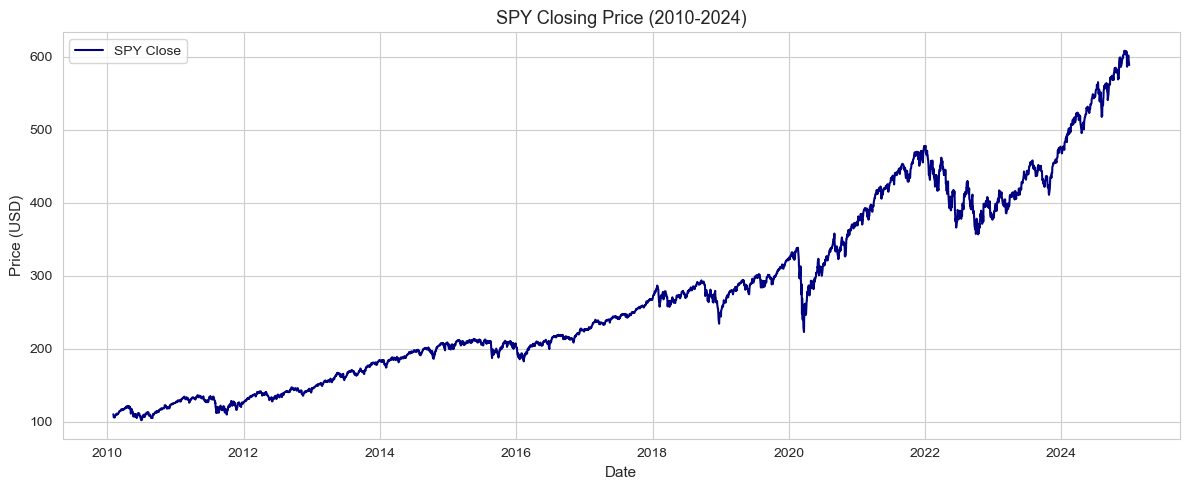


[8] Plot 2: Log returns over time


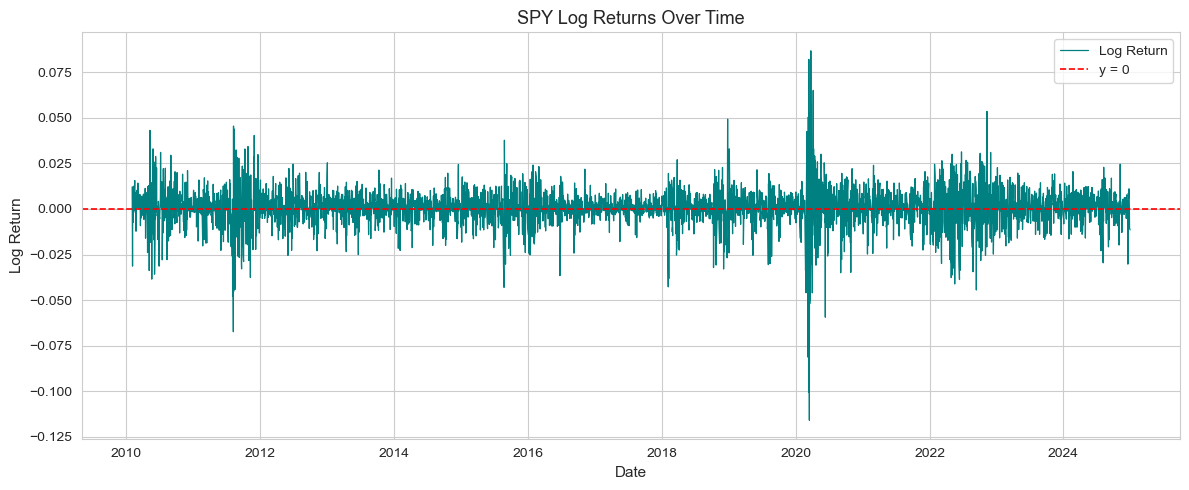


[9] Plot 3: Distribution of log returns


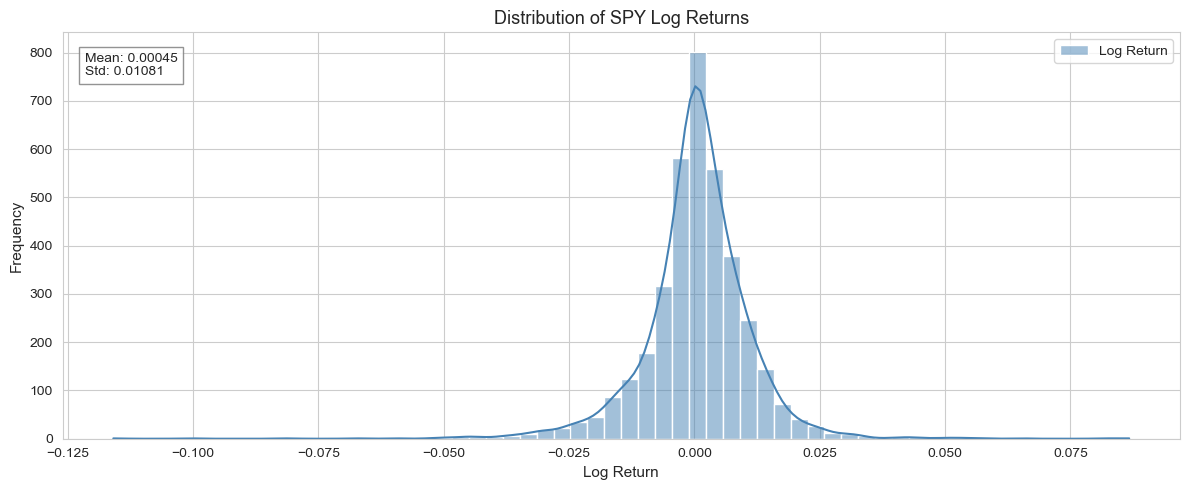


[10] Plot 4: Rolling 20-day volatility


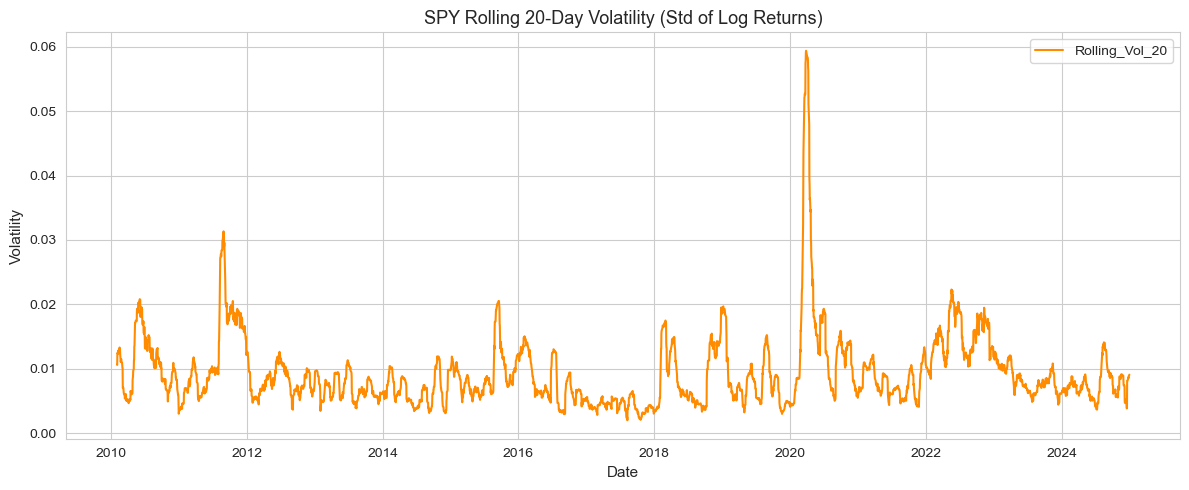


[11] Correlation matrix table
Price              Close    Volume  Log_Return  Rolling_Vol_20
Price                                                         
Close           1.000000 -0.520046    0.015112       -0.020240
Volume         -0.520046  1.000000   -0.177752        0.403630
Log_Return      0.015112 -0.177752    1.000000        0.002383
Rolling_Vol_20 -0.020240  0.403630    0.002383        1.000000

[12] Correlation heatmap


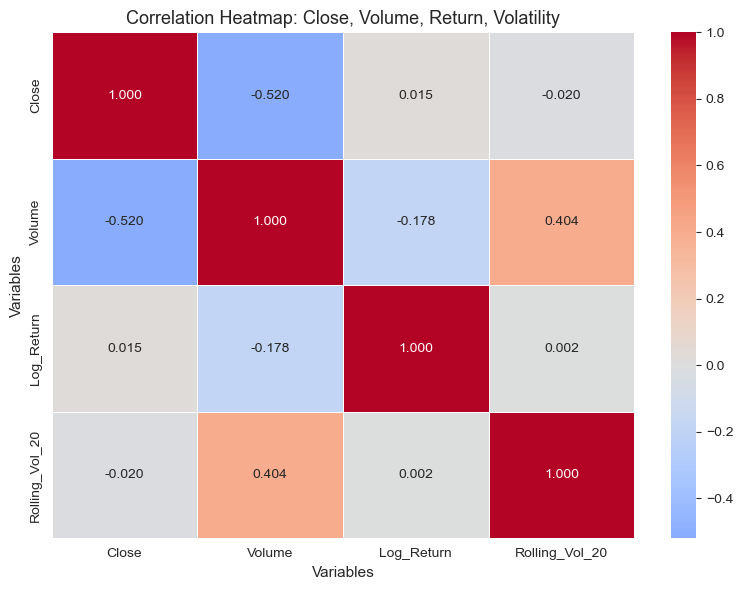

In [83]:
# ── Section 5: Visualize Results ──

print_block("[7] Plot 1: SPY closing price")
plt.figure()
plt.plot(spy_df.index, spy_df["Close"], color="navy", label="SPY Close")
plt.title("SPY Closing Price (2010-2024)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

print_block("[8] Plot 2: Log returns over time")
plt.figure()
plt.plot(spy_df.index, spy_df["Log_Return"], color="teal", linewidth=0.9, label="Log Return")
plt.axhline(0, color="red", linestyle="--", linewidth=1.2, label="y = 0")
plt.title("SPY Log Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()

print_block("[9] Plot 3: Distribution of log returns")
ret_mean = spy_df["Log_Return"].mean()
ret_std = spy_df["Log_Return"].std()

plt.figure()
sns.histplot(
    spy_df["Log_Return"],
    bins=60,
    kde=True,
    color="steelblue",
    edgecolor="white",
    label="Log Return",
)
plt.title("Distribution of SPY Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.text(
    0.02,
    0.95,
    f"Mean: {ret_mean:.5f}\nStd: {ret_std:.5f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"),
)
plt.legend()
plt.tight_layout()
plt.show()

print_block("[10] Plot 4: Rolling 20-day volatility")
plt.figure()
plt.plot(spy_df.index, spy_df["Rolling_Vol_20"], color="darkorange", label="Rolling_Vol_20")
plt.title("SPY Rolling 20-Day Volatility (Std of Log Returns)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

print_block("[11] Correlation matrix table")
corr_cols = ["Close", "Volume", "Log_Return", "Rolling_Vol_20"]
corr_matrix = spy_df[corr_cols].corr()
print(corr_matrix)

print_block("[12] Correlation heatmap")
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap: Close, Volume, Return, Volatility")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [84]:
# ── Section 6: Save Artifacts and Export Outputs ──
print_block("[13] Saving cleaned dataset")
spy_df.to_csv(OUTPUT_CSV)
print(f"Saved file: {OUTPUT_CSV}")
print("EDA complete. Data saved to spy_raw.csv")


[13] Saving cleaned dataset
Saved file: spy_raw.csv
EDA complete. Data saved to spy_raw.csv


## Section 2: Ground Truth Label Generation

In this section, we generate regime labels using three independent approaches and compare their consistency before creating a majority-vote final label.

In [85]:
# ── Section 2A: Setup, Data Load, and Shared Helpers ──
print_block("[Section 2] Loading spy_raw.csv")
labels_df = pd.read_csv("spy_raw.csv", parse_dates=[0], index_col=0)
labels_df.index = pd.to_datetime(labels_df.index)
labels_df = labels_df.sort_index()
validate_dataframe(labels_df, label="Section 2 input data")

print(f"Input shape: {labels_df.shape}")
print(f"Date span: {labels_df.index.min().date()} to {labels_df.index.max().date()}")


def print_class_distribution(series: pd.Series, label_name: str) -> pd.DataFrame:
    """Print count and percentage per class for readable reporting."""
    dist = series.value_counts(dropna=False).rename_axis("Class").to_frame("Count")
    dist["Percent"] = (dist["Count"] / dist["Count"].sum() * 100).round(2)
    print_block(f"{label_name} class distribution")
    print(dist)
    return dist


def assign_regime_labels(values: pd.Series, trend_thr: float, mr_thr: float) -> pd.Series:
    labels = np.where(values > trend_thr, "Trending", np.where(values < mr_thr, "MeanReverting", "Neutral"))
    return pd.Series(labels, index=values.index)


def hurst_rs(window_returns: pd.Series) -> float:
    """Compute Hurst exponent via classic R/S analysis (from scratch)."""
    x = window_returns.dropna().values
    n_obs = len(x)
    if n_obs < 20:
        return np.nan

    chunk_sizes = [5, 10, 15, 20, 30]
    chunk_sizes = [c for c in chunk_sizes if c < n_obs]

    rs_pairs = []
    for chunk_size in chunk_sizes:
        n_chunks = n_obs // chunk_size
        if n_chunks < 2:
            continue

        rs_values = []
        for i in range(n_chunks):
            chunk = x[i * chunk_size:(i + 1) * chunk_size]
            centered = chunk - chunk.mean()
            cumulative = np.cumsum(centered)
            r = cumulative.max() - cumulative.min()
            s = chunk.std(ddof=1)
            if s > 0:
                rs_values.append(r / s)

        if len(rs_values) > 0:
            rs_pairs.append((chunk_size, np.mean(rs_values)))

    if len(rs_pairs) < 2:
        return np.nan

    log_n = np.log([p[0] for p in rs_pairs])
    log_rs = np.log([p[1] for p in rs_pairs])
    hurst, _ = np.polyfit(log_n, log_rs, 1)
    return float(hurst)


def variance_ratio(window_returns: pd.Series, k: int = 5) -> float:
    """Simplified Lo-MacKinlay variance ratio on a rolling window."""
    r = window_returns.dropna()
    if len(r) <= k + 1:
        return np.nan

    var_1 = np.var(r, ddof=1)
    if var_1 == 0:
        return np.nan

    k_period_returns = r.rolling(k).sum().dropna()
    if len(k_period_returns) < 2:
        return np.nan

    var_k = np.var(k_period_returns, ddof=1)
    return float(var_k / (k * var_1))


[Section 2] Loading spy_raw.csv
Input shape: (3753, 8)
Date span: 2010-02-02 to 2024-12-30


In [86]:
# ── Section 2B: Method A — Hurst Exponent (R/S Analysis) ──
print_block("[Method A] Rolling Hurst exponent (window=60)")
labels_df["Hurst_60"] = labels_df["Log_Return"].rolling(window=60).apply(hurst_rs, raw=False)
labels_df["Label_Hurst"] = assign_regime_labels(labels_df["Hurst_60"], trend_thr=0.55, mr_thr=0.45)
_ = print_class_distribution(labels_df["Label_Hurst"], "Method A (Hurst)")

# ── Section 2C: Method B — Variance Ratio (Lo-MacKinlay Simplified) ──
print_block("[Method B] Rolling variance ratio (window=60, k=5)")
labels_df["VR_60_k5"] = labels_df["Log_Return"].rolling(window=60).apply(lambda x: variance_ratio(x, k=5), raw=False)
labels_df["Label_VR"] = assign_regime_labels(labels_df["VR_60_k5"], trend_thr=1.1, mr_thr=0.9)
_ = print_class_distribution(labels_df["Label_VR"], "Method B (Variance Ratio)")

# ── Section 2D: Method C — Rolling Return Autocorrelation ──
print_block("[Method C] Rolling lag-1 autocorrelation (window=30)")
labels_df["Autocorr_30"] = labels_df["Log_Return"].rolling(window=30).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)
labels_df["Label_Autocorr"] = assign_regime_labels(labels_df["Autocorr_30"], trend_thr=0.1, mr_thr=-0.1)
_ = print_class_distribution(labels_df["Label_Autocorr"], "Method C (Autocorrelation)")


[Method A] Rolling Hurst exponent (window=60)

Method A (Hurst) class distribution
               Count  Percent
Class                        
Trending        3321    88.49
Neutral          385    10.26
MeanReverting     47     1.25

[Method B] Rolling variance ratio (window=60, k=5)

Method B (Variance Ratio) class distribution
               Count  Percent
Class                        
MeanReverting   2252    60.01
Neutral         1037    27.63
Trending         464    12.36

[Method C] Rolling lag-1 autocorrelation (window=30)

Method C (Autocorrelation) class distribution
               Count  Percent
Class                        
Neutral         1589    42.34
MeanReverting   1556    41.46
Trending         608    16.20



[Comparison] Combined label sample
                 Close Label_Hurst Label_VR Label_Autocorr
Date                                                      
2010-02-02  110.379997     Neutral  Neutral        Neutral
2010-02-03  109.830002     Neutral  Neutral        Neutral
2010-02-04  106.440002     Neutral  Neutral        Neutral
2010-02-05  106.660004     Neutral  Neutral        Neutral
2010-02-08  105.889999     Neutral  Neutral        Neutral

[Comparison] Pairwise agreement matrix (%)
                Label_Hurst  Label_VR  Label_Autocorr
Label_Hurst          100.00     15.29           21.21
Label_VR              15.29    100.00           49.05
Label_Autocorr        21.21     49.05          100.00

[Comparison] All-three agreement
% of days where all 3 methods agree: 5.84%

[Comparison] Plotting price and regime bands


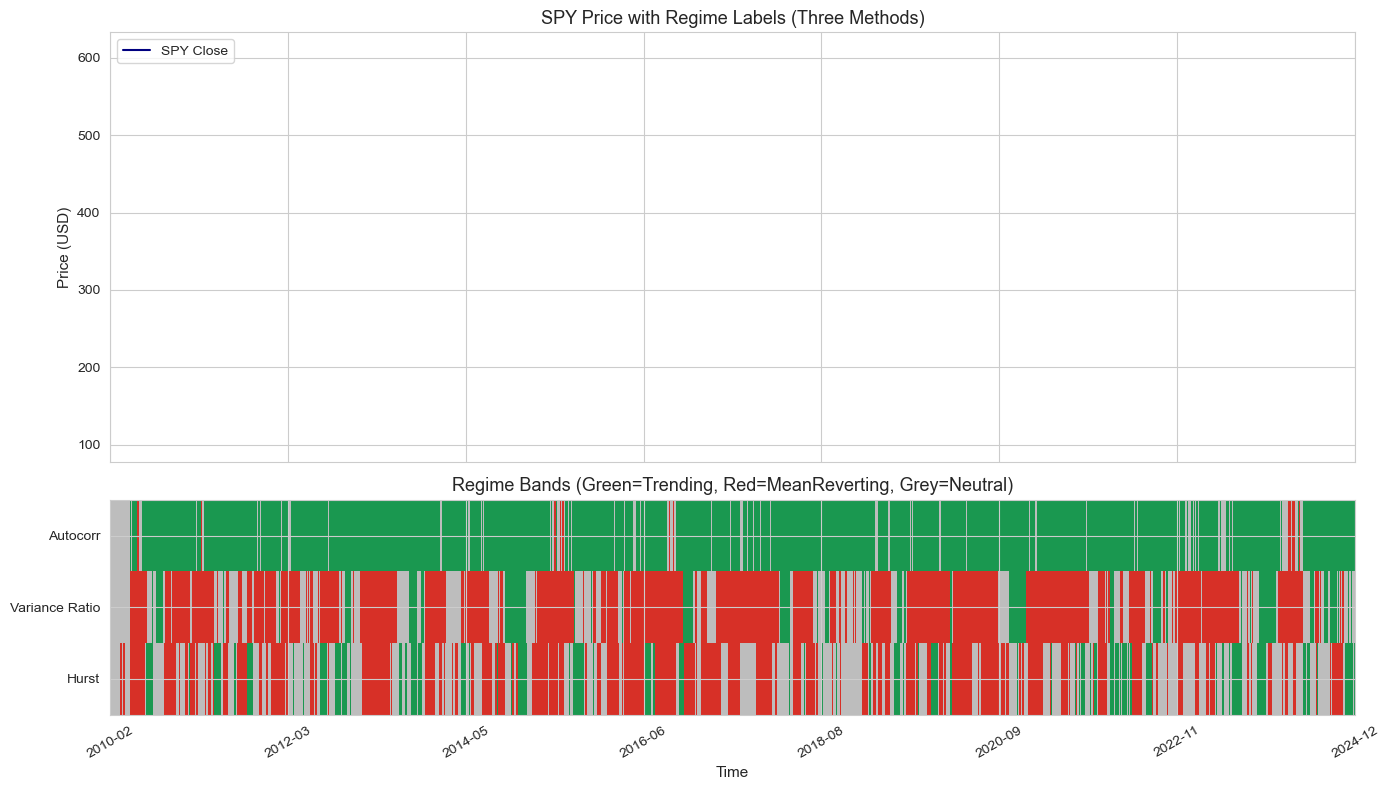


[Comparison] Cleanest label method (least Neutral)
Neutral percentages:
- Label_Hurst: 10.26%
- Label_VR: 27.63%
- Label_Autocorr: 42.34%
Cleanest method: Label_Hurst

[Final Decision] Final_Label distribution

Final_Label class distribution
               Count  Percent
Class                        
MeanReverting   1198    43.20
Trending         916    33.03
Neutral          659    23.76
Saved: trend_labels.csv


In [87]:
# ── Section 2E: Compare Methods and Build Final Label ──
label_cols = ["Label_Hurst", "Label_VR", "Label_Autocorr"]
combined_labels = labels_df[["Close"] + label_cols].copy()

print_block("[Comparison] Combined label sample")
print(combined_labels.head())

# Pairwise agreement matrix (% of days with same class)
agreement_matrix = pd.DataFrame(index=label_cols, columns=label_cols, dtype=float)
for c1 in label_cols:
    for c2 in label_cols:
        agreement_matrix.loc[c1, c2] = (combined_labels[c1] == combined_labels[c2]).mean() * 100

print_block("[Comparison] Pairwise agreement matrix (%)")
print(agreement_matrix.round(2))

all_three_agree_pct = ((combined_labels["Label_Hurst"] == combined_labels["Label_VR"]) &
                       (combined_labels["Label_VR"] == combined_labels["Label_Autocorr"])).mean() * 100
print_block("[Comparison] All-three agreement")
print(f"% of days where all 3 methods agree: {all_three_agree_pct:.2f}%")

# Plot price and colored regime bands for all 3 methods
print_block("[Comparison] Plotting price and regime bands")
label_to_num = {"MeanReverting": 0, "Neutral": 1, "Trending": 2}
num_to_color = ["#d73027", "#bdbdbd", "#1a9850"]  # red, gray, green

label_matrix = np.vstack([
    combined_labels["Label_Hurst"].map(label_to_num).fillna(1).values,
    combined_labels["Label_VR"].map(label_to_num).fillna(1).values,
    combined_labels["Label_Autocorr"].map(label_to_num).fillna(1).values,
])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(combined_labels.index, combined_labels["Close"], color="navy", label="SPY Close")
axes[0].set_title("SPY Price with Regime Labels (Three Methods)")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")

from matplotlib.colors import ListedColormap
cmap = ListedColormap(num_to_color)
axes[1].imshow(
    label_matrix,
    aspect="auto",
    cmap=cmap,
    interpolation="nearest",
    extent=[0, len(combined_labels) - 1, 0, 3],
)
axes[1].set_yticks([0.5, 1.5, 2.5])
axes[1].set_yticklabels(["Hurst", "Variance Ratio", "Autocorr"])
axes[1].set_title("Regime Bands (Green=Trending, Red=MeanReverting, Grey=Neutral)")
axes[1].set_xlabel("Time")

# Put sensible date ticks on x-axis by mapping index positions.
tick_positions = np.linspace(0, len(combined_labels) - 1, 8, dtype=int)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels([combined_labels.index[i].strftime("%Y-%m") for i in tick_positions], rotation=30)

plt.tight_layout()
plt.show()

neutral_pct = {col: (combined_labels[col] == "Neutral").mean() * 100 for col in label_cols}
cleanest_method = min(neutral_pct, key=neutral_pct.get)
print_block("[Comparison] Cleanest label method (least Neutral)")
print("Neutral percentages:")
for method_name, pct in neutral_pct.items():
    print(f"- {method_name}: {pct:.2f}%")
print(f"Cleanest method: {cleanest_method}")


def majority_vote(row: pd.Series) -> str:
    counts = row.value_counts()
    if counts.max() >= 2:
        return counts.idxmax()
    return "Neutral"

# Drop rows where all 3 methods disagree (each method picks a different class).
all_disagree_mask = combined_labels[label_cols].nunique(axis=1) == 3
labels_filtered = labels_df.loc[~all_disagree_mask].copy()
labels_filtered["Final_Label"] = labels_filtered[label_cols].apply(majority_vote, axis=1)
print_block("[Final Decision] Final_Label distribution")
_ = print_class_distribution(labels_filtered["Final_Label"], "Final_Label")

labels_filtered.to_csv("trend_labels.csv")
print("Saved: trend_labels.csv")

## Section 3: Feature Engineering

Build model-ready features in logical groups and verify each step with clear progress prints.

In [88]:
# ── Section 3A: Load Labels and Define Helpers ──
print_block("[Section 3] Loading trend_labels.csv")
feat_df = pd.read_csv("trend_labels.csv", parse_dates=[0], index_col=0)
feat_df.index = pd.to_datetime(feat_df.index)
feat_df = feat_df.sort_index()
validate_dataframe(feat_df, label="Section 3 input data")
# Drop intermediate regime columns from Section 2 to prevent passive leakage
leakage_cols = [
    "Hurst_60", "VR_60_k5", "Autocorr_30", 
    "Label_Hurst", "Label_VR", "Label_Autocorr"
]
feat_df = feat_df.drop(columns=[c for c in leakage_cols if c in feat_df.columns])
print(f"Input shape: {feat_df.shape}")
print(f"Date span: {feat_df.index.min().date()} to {feat_df.index.max().date()}")


def report_feature_group(group_name: str, before_cols: set, after_cols: set) -> list:
    new_cols = sorted(list(after_cols - before_cols))
    print_block(f"[Feature Group] {group_name}")
    print(f"Features added: {len(new_cols)}")
    if new_cols:
        print(new_cols)
    return new_cols


[Section 3] Loading trend_labels.csv
Input shape: (2773, 9)
Date span: 2010-02-02 to 2024-12-30


In [89]:
# ── Section 3B: Build Feature Groups ──
all_engineered_features = []

# Group 1 — Return-based features
before = set(feat_df.columns)
feat_df["Ret_Mean_5"] = feat_df["Log_Return"].rolling(5).mean()
feat_df["Ret_Mean_10"] = feat_df["Log_Return"].rolling(10).mean()
feat_df["Ret_Mean_20"] = feat_df["Log_Return"].rolling(20).mean()
feat_df["Ret_Std_5"] = feat_df["Log_Return"].rolling(5).std()
feat_df["Ret_Std_20"] = feat_df["Log_Return"].rolling(20).std()
feat_df["CumRet_10"] = feat_df["Log_Return"].rolling(10).sum()
feat_df["CumRet_20"] = feat_df["Log_Return"].rolling(20).sum()
after = set(feat_df.columns)
all_engineered_features += report_feature_group("Group 1 — Return-based", before, after)

# Group 2 — Trend indicators
before = set(feat_df.columns)
feat_df["SMA_20"] = feat_df["Close"].rolling(20).mean()
feat_df["SMA_50"] = feat_df["Close"].rolling(50).mean()
feat_df["SMA_200"] = feat_df["Close"].rolling(200).mean()
feat_df["SMA_Ratio_50_200"] = feat_df["SMA_50"] / feat_df["SMA_200"]
feat_df["Price_Dist_SMA20"] = (feat_df["Close"] - feat_df["SMA_20"]) / feat_df["SMA_20"]
ema_12 = feat_df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = feat_df["Close"].ewm(span=26, adjust=False).mean()
feat_df["MACD"] = ema_12 - ema_26
feat_df["MACD_Signal"] = feat_df["MACD"].ewm(span=9, adjust=False).mean()
after = set(feat_df.columns)
all_engineered_features += report_feature_group("Group 2 — Trend indicators", before, after)

# Group 3 — Momentum & oscillators
before = set(feat_df.columns)
delta = feat_df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean().replace(0, np.nan)
rs = avg_gain / avg_loss
feat_df["RSI_14"] = 100 - (100 / (1 + rs))
feat_df["ROC_10"] = (feat_df["Close"] - feat_df["Close"].shift(10)) / feat_df["Close"].shift(10)
feat_df["Momentum_5"] = feat_df["Close"] - feat_df["Close"].shift(5)
after = set(feat_df.columns)
all_engineered_features += report_feature_group("Group 3 — Momentum & Oscillators", before, after)

# Group 4 — Volatility & range
before = set(feat_df.columns)
bb_mid = feat_df["Close"].rolling(20).mean()
bb_std = feat_df["Close"].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
feat_df["BB_Width_20_2"] = (bb_upper - bb_lower) / bb_mid

prev_close = feat_df["Close"].shift(1)
tr_1 = feat_df["High"] - feat_df["Low"]
tr_2 = (feat_df["High"] - prev_close).abs()
tr_3 = (feat_df["Low"] - prev_close).abs()
true_range = pd.concat([tr_1, tr_2, tr_3], axis=1).max(axis=1)
feat_df["ATR_14"] = true_range.ewm(span=14, adjust=False).mean()
feat_df["HL_Range_Norm"] = (feat_df["High"] - feat_df["Low"]) / feat_df["Close"]
after = set(feat_df.columns)
all_engineered_features += report_feature_group("Group 4 — Volatility & Range", before, after)

# Group 5 — Statistical / regime-specific
before = set(feat_df.columns)
feat_df["Skew_20"] = feat_df["Log_Return"].rolling(20).skew()
feat_df["Kurt_20"] = feat_df["Log_Return"].rolling(20).kurt()
after = set(feat_df.columns)
all_engineered_features += report_feature_group("Group 5 — Statistical / Regime-specific", before, after)


[Feature Group] Group 1 — Return-based
Features added: 7
['CumRet_10', 'CumRet_20', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Mean_5', 'Ret_Std_20', 'Ret_Std_5']

[Feature Group] Group 2 — Trend indicators
Features added: 7
['MACD', 'MACD_Signal', 'Price_Dist_SMA20', 'SMA_20', 'SMA_200', 'SMA_50', 'SMA_Ratio_50_200']

[Feature Group] Group 3 — Momentum & Oscillators
Features added: 3
['Momentum_5', 'ROC_10', 'RSI_14']

[Feature Group] Group 4 — Volatility & Range
Features added: 3
['ATR_14', 'BB_Width_20_2', 'HL_Range_Norm']

[Feature Group] Group 5 — Statistical / Regime-specific
Features added: 2
['Kurt_20', 'Skew_20']



[Section 3] Drop rows with NaN values
Final DataFrame shape after dropna: (2574, 31)

[Section 3] Feature list used for modeling
Total engineered features: 24
['ATR_14', 'BB_Width_20_2', 'CumRet_10', 'CumRet_20', 'HL_Range_Norm', 'Kurt_20', 'Log_Return', 'MACD', 'MACD_Signal', 'Momentum_5', 'Price_Dist_SMA20', 'ROC_10', 'RSI_14', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Mean_5', 'Ret_Std_20', 'Ret_Std_5', 'Rolling_Vol_20', 'SMA_20', 'SMA_200', 'SMA_50', 'SMA_Ratio_50_200', 'Skew_20']

[Section 3] Descriptive statistics of engineered features
                   count        mean         std         min         25%  \
ATR_14            2574.0    3.798971    2.654162    0.982092    1.789891   
BB_Width_20_2     2574.0    0.071224    0.046452    0.009992    0.043008   
CumRet_10         2574.0    0.004003    0.029081   -0.207020   -0.008558   
CumRet_20         2574.0    0.008119    0.039917   -0.248319   -0.008692   
HL_Range_Norm     2574.0    0.011234    0.008643    0.001229    0.006033   
K

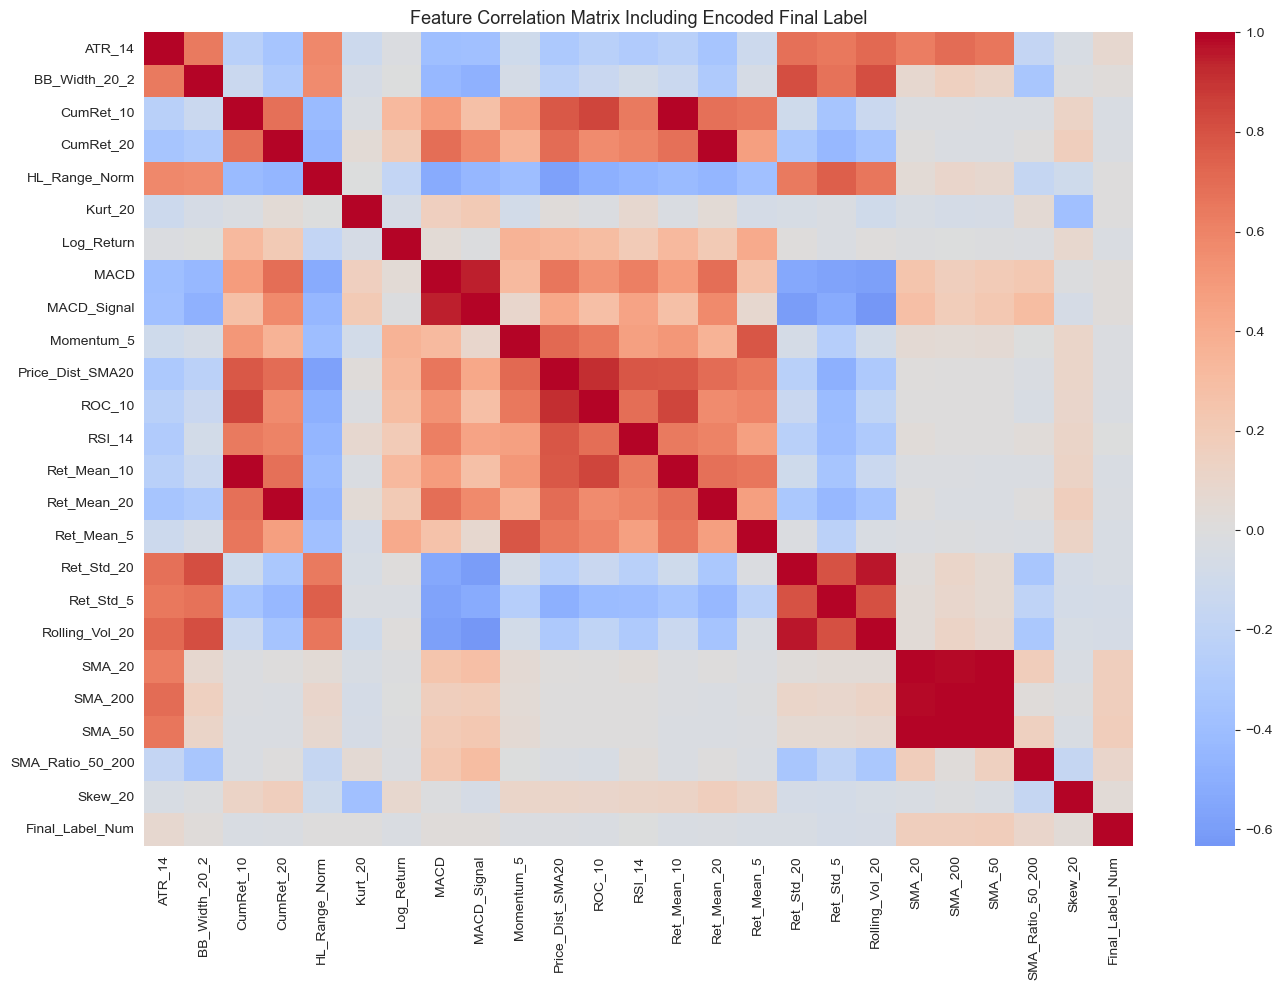


[Section 3] Top 10 most correlated features with Final_Label
                  Correlation_with_Label
SMA_50                          0.172596
SMA_20                          0.170174
SMA_200                         0.164448
SMA_Ratio_50_200                0.097056
ATR_14                          0.070013
Ret_Std_5                      -0.062481
Rolling_Vol_20                 -0.056787
Ret_Std_20                     -0.044406
Ret_Mean_5                     -0.043619
Skew_20                         0.035956
Saved: trend_features.csv


In [90]:
# ── Section 3C: Finalize Features, Diagnostics, and Export ──
print_block("[Section 3] Drop rows with NaN values")
feat_df = feat_df.dropna().copy()
print(f"Final DataFrame shape after dropna: {feat_df.shape}")

engineered_feature_cols = sorted(list(set(all_engineered_features + ["Log_Return", "Rolling_Vol_20"])))
engineered_feature_cols = [c for c in engineered_feature_cols if c in feat_df.columns]

print_block("[Section 3] Feature list used for modeling")
print(f"Total engineered features: {len(engineered_feature_cols)}")
print(engineered_feature_cols)

print_block("[Section 3] Descriptive statistics of engineered features")
print(feat_df[engineered_feature_cols].describe().T)

# Correlation heatmap with encoded label for quick linear relevance check.
label_map_3 = {"MeanReverting": 0, "Neutral": 1, "Trending": 2}
feat_df["Final_Label_Num"] = feat_df["Final_Label"].map(label_map_3)

corr_cols = engineered_feature_cols + ["Final_Label_Num"]
corr_mat = feat_df[corr_cols].corr()

print_block("[Section 3] Correlation heatmap (features vs Final_Label)")
plt.figure(figsize=(14, 10))
sns.heatmap(corr_mat, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix Including Encoded Final Label")
plt.tight_layout()
plt.show()

label_corr = corr_mat["Final_Label_Num"].drop("Final_Label_Num").sort_values(key=np.abs, ascending=False)
print_block("[Section 3] Top 10 most correlated features with Final_Label")
print(label_corr.head(10).to_frame("Correlation_with_Label"))

feat_df.to_csv("trend_features.csv")
print("Saved: trend_features.csv")

## Section 4: Model Training and Comparison

Train and evaluate four models on a strict time-based split for binary regime classification.

In [91]:
# ── Section 4A: Imports, Data Load, and Split ──
# Optional install line for fresh Colab runtimes:
# !pip install -q scikit-learn xgboost hmmlearn joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBClassifier
import joblib

print_block("[Section 4] Loading trend_features.csv")
model_df = pd.read_csv("trend_features.csv", parse_dates=[0], index_col=0)
model_df.index = pd.to_datetime(model_df.index)
model_df = model_df.sort_index()
validate_dataframe(model_df, label="Section 4 input data")

# Binary setup requested: keep only Trending / MeanReverting
model_df = model_df[model_df["Final_Label"].isin(["Trending", "MeanReverting"])].copy()
model_df["Target"] = model_df["Final_Label"].map({"Trending": 1, "MeanReverting": 0})

exclude_cols = {
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Label_Hurst", "Label_VR", "Label_Autocorr", "Final_Label", "Final_Label_Num", "Target"
}
feature_cols = [c for c in model_df.columns if c not in exclude_cols]

print_block("[Section 4] Feature set")
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)

train_mask = (model_df.index >= "2010-01-01") & (model_df.index <= "2020-12-31")
val_mask = (model_df.index >= "2021-01-01") & (model_df.index <= "2022-12-31")
test_mask = (model_df.index >= "2023-01-01") & (model_df.index <= "2024-12-31")

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, "Target"]
X_val = model_df.loc[val_mask, feature_cols]
y_val = model_df.loc[val_mask, "Target"]
X_test = model_df.loc[test_mask, feature_cols]
y_test = model_df.loc[test_mask, "Target"]

print_block("[Section 4] Time-based split sizes")
print(f"Train size (2010-2020): {len(X_train)}")
print(f"Validation size (2021-2022): {len(X_val)}")
print(f"Test size (2023-2024): {len(X_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)


def print_model_box(model_name: str, train_acc: float, val_acc: float, test_acc: float, test_f1: float) -> None:
    print("╔══════════════════════════════╗")
    print(f"║  Model: {model_name:<20}║")
    print("╠══════════════════════════════╣")
    print(f"║  Train Accuracy : {train_acc:.2f}       ║")
    print(f"║  Val   Accuracy : {val_acc:.2f}       ║")
    print(f"║  Test  Accuracy : {test_acc:.2f}       ║")
    print(f"║  Test  F1 Score : {test_f1:.2f}       ║")
    print("╚══════════════════════════════╝")


[Section 4] Loading trend_features.csv

[Section 4] Feature set
Feature count: 24
['Log_Return', 'Rolling_Vol_20', 'Ret_Mean_5', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Std_5', 'Ret_Std_20', 'CumRet_10', 'CumRet_20', 'SMA_20', 'SMA_50', 'SMA_200', 'SMA_Ratio_50_200', 'Price_Dist_SMA20', 'MACD', 'MACD_Signal', 'RSI_14', 'ROC_10', 'Momentum_5', 'BB_Width_20_2', 'ATR_14', 'HL_Range_Norm', 'Skew_20', 'Kurt_20']

[Section 4] Time-based split sizes
Train size (2010-2020): 1425
Validation size (2021-2022): 283
Test size (2023-2024): 278


╔══════════════════════════════╗
║  Model: Logistic Regression ║
╠══════════════════════════════╣
║  Train Accuracy : 0.69       ║
║  Val   Accuracy : 0.39       ║
║  Test  Accuracy : 0.37       ║
║  Test  F1 Score : 0.35       ║
╚══════════════════════════════╝

Logistic Regression - Classification Report (Test)
               precision    recall  f1-score   support

MeanReverting       0.28      0.65      0.39        85
     Trending       0.62      0.25      0.35       193

     accuracy                           0.37       278
    macro avg       0.45      0.45      0.37       278
 weighted avg       0.51      0.37      0.36       278



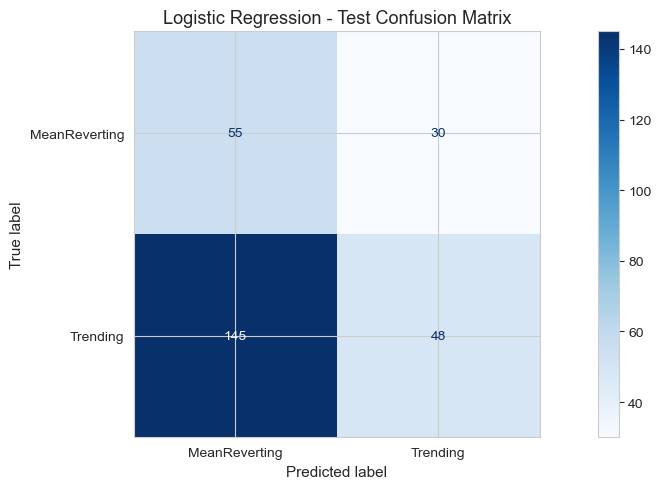

╔══════════════════════════════╗
║  Model: Random Forest       ║
╠══════════════════════════════╣
║  Train Accuracy : 0.89       ║
║  Val   Accuracy : 0.52       ║
║  Test  Accuracy : 0.69       ║
║  Test  F1 Score : 0.82       ║
╚══════════════════════════════╝

Random Forest - Classification Report (Test)
               precision    recall  f1-score   support

MeanReverting       0.00      0.00      0.00        85
     Trending       0.69      1.00      0.82       193

     accuracy                           0.69       278
    macro avg       0.35      0.50      0.41       278
 weighted avg       0.48      0.69      0.57       278



c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


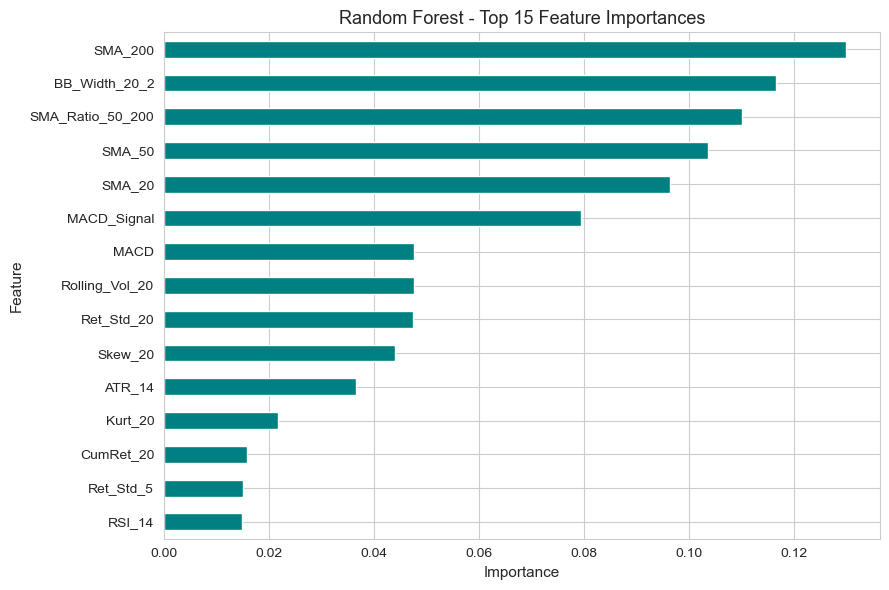

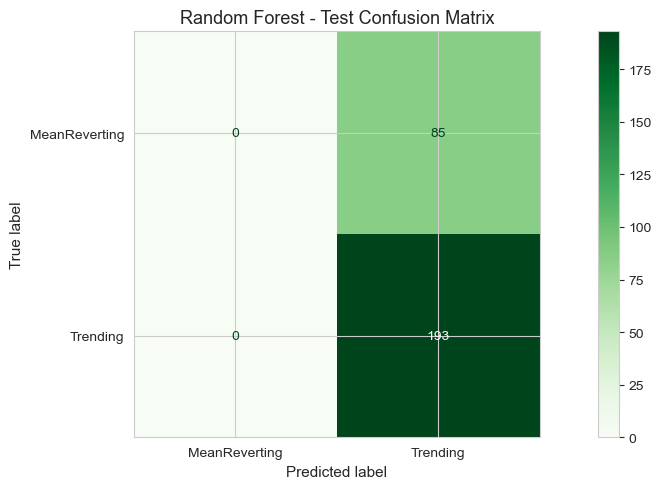

╔══════════════════════════════╗
║  Model: XGBoost             ║
╠══════════════════════════════╣
║  Train Accuracy : 0.99       ║
║  Val   Accuracy : 0.36       ║
║  Test  Accuracy : 0.72       ║
║  Test  F1 Score : 0.81       ║
╚══════════════════════════════╝

XGBoost - Classification Report (Test)
               precision    recall  f1-score   support

MeanReverting       0.56      0.34      0.42        85
     Trending       0.75      0.88      0.81       193

     accuracy                           0.72       278
    macro avg       0.65      0.61      0.62       278
 weighted avg       0.69      0.72      0.69       278



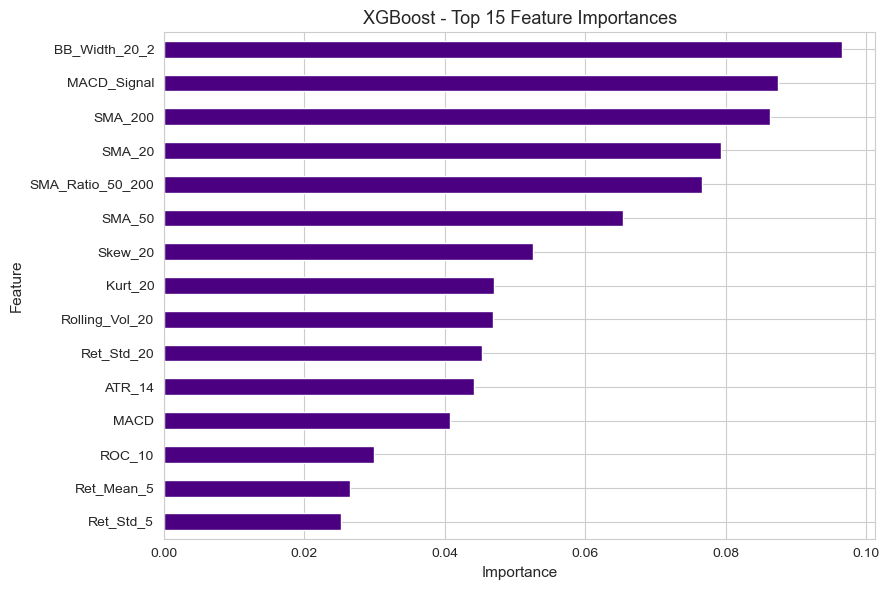

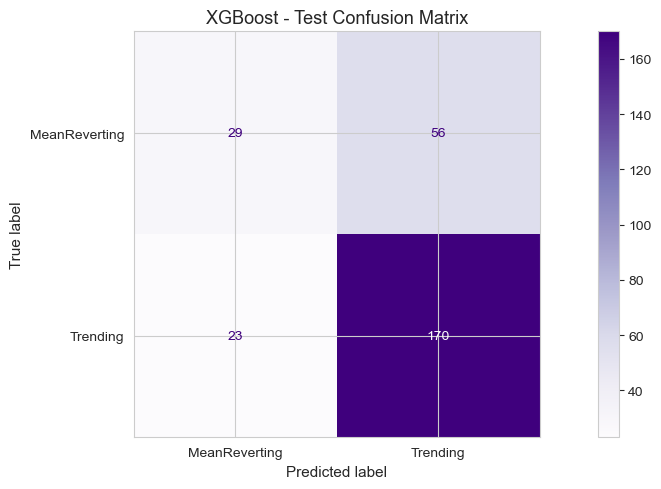

In [92]:
# ── Section 4B: Train and Evaluate Models ──
model_results = {}
model_objects = {}
model_hyperparams = {}

# Model 1 — Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)

pred_train_lr = log_reg.predict(X_train_sc)
pred_val_lr = log_reg.predict(X_val_sc)
pred_test_lr = log_reg.predict(X_test_sc)

metrics_lr = {
    "train_acc": accuracy_score(y_train, pred_train_lr),
    "val_acc": accuracy_score(y_val, pred_val_lr),
    "test_acc": accuracy_score(y_test, pred_test_lr),
    "test_f1": f1_score(y_test, pred_test_lr),
    "y_test_pred": pred_test_lr,
}
model_results["Logistic Regression"] = metrics_lr
model_objects["Logistic Regression"] = log_reg
model_hyperparams["Logistic Regression"] = {"max_iter": 1000}

print_model_box("Logistic Regression", metrics_lr["train_acc"], metrics_lr["val_acc"], metrics_lr["test_acc"], metrics_lr["test_f1"])
print_block("Logistic Regression - Classification Report (Test)")
print(classification_report(y_test, pred_test_lr, target_names=["MeanReverting", "Trending"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test_lr, display_labels=["MeanReverting", "Trending"], cmap="Blues")
plt.title("Logistic Regression - Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
)
rf.fit(X_train_sc, y_train)

pred_train_rf = rf.predict(X_train_sc)
pred_val_rf = rf.predict(X_val_sc)
pred_test_rf = rf.predict(X_test_sc)

metrics_rf = {
    "train_acc": accuracy_score(y_train, pred_train_rf),
    "val_acc": accuracy_score(y_val, pred_val_rf),
    "test_acc": accuracy_score(y_test, pred_test_rf),
    "test_f1": f1_score(y_test, pred_test_rf),
    "y_test_pred": pred_test_rf,
}
model_results["Random Forest"] = metrics_rf
model_objects["Random Forest"] = rf
model_hyperparams["Random Forest"] = {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 10, "random_state": 42}

print_model_box("Random Forest", metrics_rf["train_acc"], metrics_rf["val_acc"], metrics_rf["test_acc"], metrics_rf["test_f1"])
print_block("Random Forest - Classification Report (Test)")
print(classification_report(y_test, pred_test_rf, target_names=["MeanReverting", "Trending"]))

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
rf_importance.sort_values().plot(kind="barh", color="teal")
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred_test_rf, display_labels=["MeanReverting", "Trending"], cmap="Greens")
plt.title("Random Forest - Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Model 3 — XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss",
)
xgb_model.fit(X_train_sc, y_train)

pred_train_xgb = xgb_model.predict(X_train_sc)
pred_val_xgb = xgb_model.predict(X_val_sc)
pred_test_xgb = xgb_model.predict(X_test_sc)

metrics_xgb = {
    "train_acc": accuracy_score(y_train, pred_train_xgb),
    "val_acc": accuracy_score(y_val, pred_val_xgb),
    "test_acc": accuracy_score(y_test, pred_test_xgb),
    "test_f1": f1_score(y_test, pred_test_xgb),
    "y_test_pred": pred_test_xgb,
}
model_results["XGBoost"] = metrics_xgb
model_objects["XGBoost"] = xgb_model
model_hyperparams["XGBoost"] = {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "random_state": 42}

print_model_box("XGBoost", metrics_xgb["train_acc"], metrics_xgb["val_acc"], metrics_xgb["test_acc"], metrics_xgb["test_f1"])
print_block("XGBoost - Classification Report (Test)")
print(classification_report(y_test, pred_test_xgb, target_names=["MeanReverting", "Trending"]))

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
xgb_importance.sort_values().plot(kind="barh", color="indigo")
plt.title("XGBoost - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred_test_xgb, display_labels=["MeanReverting", "Trending"], cmap="Purples")
plt.title("XGBoost - Test Confusion Matrix")
plt.tight_layout()
plt.show()

Model is not converging.  Current: 9936.194046275903 is not greater than 10041.392944896274. Delta is -105.19889862037053
c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 


HMM state statistics (train period)
       mean_return  mean_volatility
State                              
0         0.000491         0.007528
1         0.000706         0.022615
╔══════════════════════════════╗
║  Model: Gaussian HMM        ║
╠══════════════════════════════╣
║  Train Accuracy : 0.61       ║
║  Val   Accuracy : 0.52       ║
║  Test  Accuracy : 0.31       ║
║  Test  F1 Score : 0.00       ║
╚══════════════════════════════╝

HMM - Classification Report (Test, after state alignment)
               precision    recall  f1-score   support

MeanReverting       0.31      1.00      0.47        85
     Trending       0.00      0.00      0.00       193

     accuracy                           0.31       278
    macro avg       0.15      0.50      0.23       278
 weighted avg       0.09      0.31      0.14       278



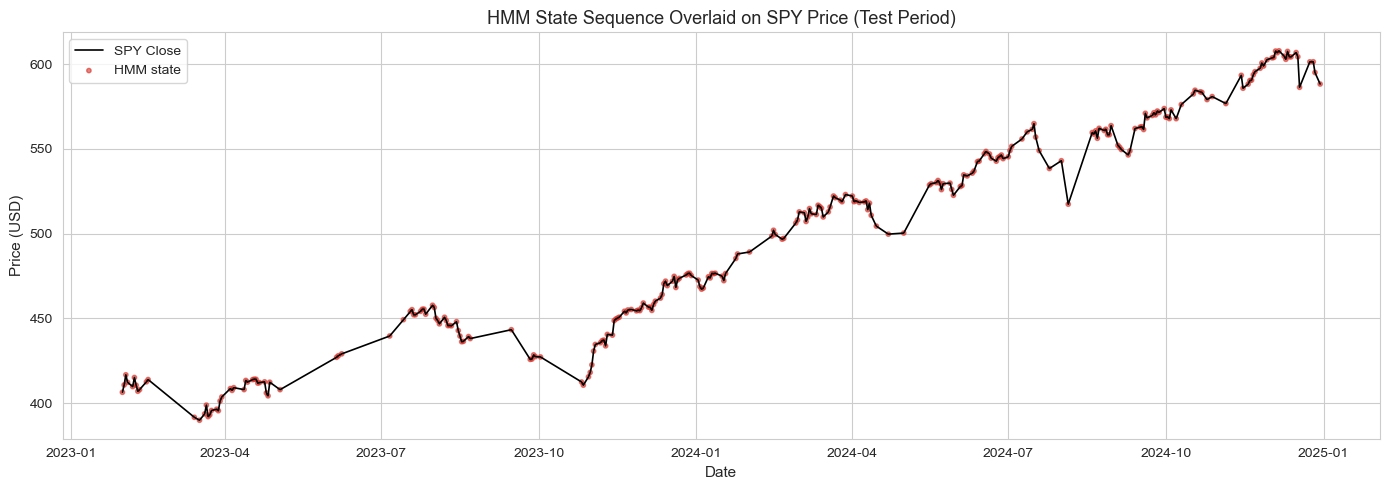


Final Comparison Table
              Model  Test Accuracy  Test F1            Notes
Logistic Regression         0.3705   0.3542         Baseline
      Random Forest         0.6942   0.8195                 
            XGBoost         0.7158   0.8115                 
 HMM (unsupervised)         0.3058   0.0000 No labels needed

Recommended model:

Based on test-set F1 score and stability across the time-based split,
I recommend: Random Forest.

Reasoning:
1) It achieved the strongest binary regime-separation quality on the holdout period.
2) It balances predictive performance with practical deployment simplicity.
3) It is suitable for downstream strategy decisions in Section 5.

Saved model artifact: trend_model.pkl
Saved scaler artifact: trend_scaler.pkl


In [93]:
# ── Section 4C: Gaussian HMM (Unsupervised) and Final Comparison ──
hmm_model = GaussianHMM(n_components=2, covariance_type="full", n_iter=200, random_state=42)
hmm_model.fit(X_train_sc)

state_train = hmm_model.predict(X_train_sc)
state_val = hmm_model.predict(X_val_sc)
state_test = hmm_model.predict(X_test_sc)

train_stats = pd.DataFrame({
    "State": state_train,
    "Return": model_df.loc[train_mask, "Log_Return"].values,
    "Volatility": model_df.loc[train_mask, "Rolling_Vol_20"].values,
})
state_summary = train_stats.groupby("State").agg(mean_return=("Return", "mean"), mean_volatility=("Volatility", "mean"))

trend_state = state_summary["mean_return"].idxmax()
state_to_label = {trend_state: 1}
for s in state_summary.index:
    if s not in state_to_label:
        state_to_label[s] = 0

pred_train_hmm = pd.Series(state_train).map(state_to_label).values
pred_val_hmm = pd.Series(state_val).map(state_to_label).values
pred_test_hmm = pd.Series(state_test).map(state_to_label).values

metrics_hmm = {
    "train_acc": accuracy_score(y_train, pred_train_hmm),
    "val_acc": accuracy_score(y_val, pred_val_hmm),
    "test_acc": accuracy_score(y_test, pred_test_hmm),
    "test_f1": f1_score(y_test, pred_test_hmm),
    "y_test_pred": pred_test_hmm,
}
model_results["HMM (unsupervised)"] = metrics_hmm
model_objects["HMM (unsupervised)"] = hmm_model
model_hyperparams["HMM (unsupervised)"] = {"n_components": 2, "covariance_type": "full", "n_iter": 200, "random_state": 42}

print_block("HMM state statistics (train period)")
print(state_summary)
print_model_box("Gaussian HMM", metrics_hmm["train_acc"], metrics_hmm["val_acc"], metrics_hmm["test_acc"], metrics_hmm["test_f1"])

print_block("HMM - Classification Report (Test, after state alignment)")
print(classification_report(y_test, pred_test_hmm, target_names=["MeanReverting", "Trending"]))

test_price = model_df.loc[test_mask, "Close"]
plt.figure(figsize=(14, 5))
plt.plot(test_price.index, test_price.values, color="black", linewidth=1.2, label="SPY Close")
plt.scatter(test_price.index, test_price.values, c=pred_test_hmm, cmap=ListedColormap(["#d73027", "#1a9850"]), s=10, alpha=0.6, label="HMM state")
plt.title("HMM State Sequence Overlaid on SPY Price (Test Period)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Final comparison table
comparison_rows = []
for name, m in model_results.items():
    note = "Baseline" if name == "Logistic Regression" else ("No labels needed" if "HMM" in name else "")
    comparison_rows.append({
        "Model": name,
        "Test Accuracy": round(m["test_acc"], 4),
        "Test F1": round(m["test_f1"], 4),
        "Notes": note,
    })
comparison_df = pd.DataFrame(comparison_rows)

print_block("Final Comparison Table")
print(comparison_df.to_string(index=False))

supervised_names = ["Logistic Regression", "Random Forest", "XGBoost"]
best_supervised_name = max(supervised_names, key=lambda n: model_results[n]["test_f1"])
best_supervised_model = model_objects[best_supervised_name]
best_supervised_f1 = model_results[best_supervised_name]["test_f1"]

print("\nRecommended model:")
print(f"""
Based on test-set F1 score and stability across the time-based split,
I recommend: {best_supervised_name}.

Reasoning:
1) It achieved the strongest binary regime-separation quality on the holdout period.
2) It balances predictive performance with practical deployment simplicity.
3) It is suitable for downstream strategy decisions in Section 5.
""")

joblib.dump(best_supervised_model, "trend_model.pkl")
joblib.dump(scaler, "trend_scaler.pkl")
print("Saved model artifact: trend_model.pkl")
print("Saved scaler artifact: trend_scaler.pkl")

## Section 5: Strategy Backtesting and MLflow Experiment Tracking

Use the best saved supervised model to run regime-based backtests on 2023-2024, then log model experiments in MLflow.


[Section 5] Loading trend_features.csv and saved artifacts

Strategy Performance Summary (2023-2024)

Strategy A (Trend-following)
  Total return (%)      : 27.98
  Annualized return (%) : 17.38
  Annualized Sharpe     : 0.99
  Maximum drawdown (%)  : -13.19
  Regime switches       : 0

Strategy B (Mean-reversion proxy)
  Total return (%)      : 0.00
  Annualized return (%) : 0.00
  Annualized Sharpe     : nan
  Maximum drawdown (%)  : 0.00
  Regime switches       : 0

Benchmark (Buy & Hold)
  Total return (%)      : 27.98
  Annualized return (%) : 17.38
  Annualized Sharpe     : 0.99
  Maximum drawdown (%)  : -13.19
  Regime switches       : 0


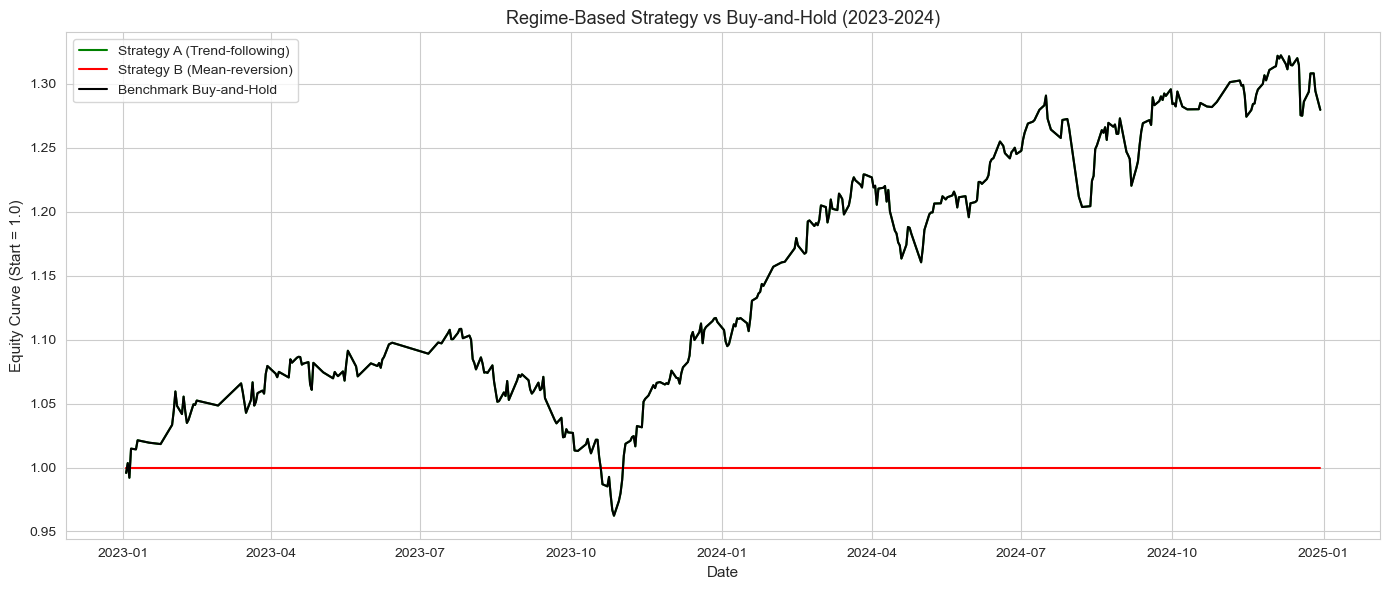

In [94]:
# ── Section 5A: Backtesting on Test Period (2023-2024) ──
# Optional install line for fresh Colab runtimes:
# !pip install -q mlflow

import mlflow
import os

print_block("[Section 5] Loading trend_features.csv and saved artifacts")
bt_df = pd.read_csv("trend_features.csv", parse_dates=[0], index_col=0)
bt_df.index = pd.to_datetime(bt_df.index)
bt_df = bt_df.sort_index()

loaded_model = joblib.load("trend_model.pkl")
loaded_scaler = joblib.load("trend_scaler.pkl")

exclude_cols_bt = {
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Label_Hurst", "Label_VR", "Label_Autocorr", "Final_Label", "Final_Label_Num", "Target"
}
bt_feature_cols = [c for c in bt_df.columns if c not in exclude_cols_bt]

test_bt_mask = (bt_df.index >= "2023-01-01") & (bt_df.index <= "2024-12-31")
bt_test = bt_df.loc[test_bt_mask].copy()

X_bt_test = bt_test[bt_feature_cols]
X_bt_test_sc = loaded_scaler.transform(X_bt_test)
pred_regime = loaded_model.predict(X_bt_test_sc)

market_log_ret = bt_test["Log_Return"].values
strategy_a_log_ret = np.where(pred_regime == 1, market_log_ret, 0.0)  # Trend-following
strategy_b_log_ret = np.where(pred_regime == 0, market_log_ret, 0.0)  # Mean-reversion proxy
benchmark_log_ret = market_log_ret.copy()


def equity_from_log_returns(log_r: np.ndarray) -> np.ndarray:
    return np.exp(np.cumsum(log_r))


def compute_performance_metrics(log_r: np.ndarray, regime_pred: np.ndarray | None = None, rf_annual: float = 0.04) -> dict:
    n = len(log_r)
    equity = equity_from_log_returns(log_r)
    total_return = equity[-1] - 1
    annualized_return = equity[-1] ** (252 / n) - 1

    rf_daily = rf_annual / 252
    ret_std = np.std(log_r, ddof=1)
    sharpe = np.nan if ret_std == 0 else ((np.mean(log_r) - rf_daily) / ret_std) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    switches = int(np.sum(regime_pred[1:] != regime_pred[:-1])) if regime_pred is not None else 0

    return {
        "equity": equity,
        "Total Return (%)": total_return * 100,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Sharpe": sharpe,
        "Max Drawdown (%)": max_drawdown * 100,
        "Regime Switches": switches,
    }


perf_a = compute_performance_metrics(strategy_a_log_ret, regime_pred=pred_regime)
perf_b = compute_performance_metrics(strategy_b_log_ret, regime_pred=pred_regime)
perf_bh = compute_performance_metrics(benchmark_log_ret)

print_block("Strategy Performance Summary (2023-2024)")
for strategy_name, perf in {
    "Strategy A (Trend-following)": perf_a,
    "Strategy B (Mean-reversion proxy)": perf_b,
    "Benchmark (Buy & Hold)": perf_bh,
}.items():
    print(f"\n{strategy_name}")
    print(f"  Total return (%)      : {perf['Total Return (%)']:.2f}")
    print(f"  Annualized return (%) : {perf['Annualized Return (%)']:.2f}")
    print(f"  Annualized Sharpe     : {perf['Annualized Sharpe']:.2f}")
    print(f"  Maximum drawdown (%)  : {perf['Max Drawdown (%)']:.2f}")
    print(f"  Regime switches       : {perf['Regime Switches']}")

plt.figure(figsize=(14, 6))
plt.plot(bt_test.index, perf_a["equity"], label="Strategy A (Trend-following)", color="green")
plt.plot(bt_test.index, perf_b["equity"], label="Strategy B (Mean-reversion)", color="red")
plt.plot(bt_test.index, perf_bh["equity"], label="Benchmark Buy-and-Hold", color="black")
plt.title("Regime-Based Strategy vs Buy-and-Hold (2023-2024)")
plt.xlabel("Date")
plt.ylabel("Equity Curve (Start = 1.0)")
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
# ── Section 5B: MLflow Logging and Final Summary ──
mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment("Trend_vs_MeanRevert_Experiment")

run_ids = {}
for model_name, metrics_dict in model_results.items():
    run_name = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    with mlflow.start_run(run_name=run_name) as run:
        run_ids[model_name] = run.info.run_id

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("feature_count", len(feature_cols))
        mlflow.log_param("train_range", "2010-01-01 to 2020-12-31")
        mlflow.log_param("test_range", "2023-01-01 to 2024-12-31")

        for hp_k, hp_v in model_hyperparams.get(model_name, {}).items():
            mlflow.log_param(hp_k, hp_v)

        mlflow.log_metric("train_accuracy", metrics_dict["train_acc"])
        mlflow.log_metric("val_accuracy", metrics_dict["val_acc"])
        mlflow.log_metric("test_accuracy", metrics_dict["test_acc"])
        mlflow.log_metric("test_f1", metrics_dict["test_f1"])

        # Per requirement, include Sharpe from backtest for best model.
        sharpe_to_log = perf_a["Annualized Sharpe"] if model_name == best_supervised_name else np.nan
        if np.isfinite(sharpe_to_log):
            mlflow.log_metric("strategy_sharpe", sharpe_to_log)

        # Save and log confusion matrix image artifact.
        cm = confusion_matrix(y_test, metrics_dict["y_test_pred"])
        fig, ax = plt.subplots(figsize=(4.5, 4))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["MeanReverting", "Trending"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Confusion Matrix - {model_name}")
        fig.tight_layout()

        cm_path = f"cm_{run_name}.png"
        fig.savefig(cm_path, dpi=130)
        plt.close(fig)
        mlflow.log_artifact(cm_path)

        # Log persisted model/scaler artifacts (if available at this point).
        if os.path.exists("trend_model.pkl"):
            mlflow.log_artifact("trend_model.pkl")
        if os.path.exists("trend_scaler.pkl"):
            mlflow.log_artifact("trend_scaler.pkl")

print_block("MLflow run IDs")
for model_name, run_id in run_ids.items():
    print(f"- {model_name}: {run_id}")

print("All experiments logged. Open MLflow UI with: mlflow ui")

best_f1_value = model_results[best_supervised_name]["test_f1"]
best_sharpe = perf_a["Annualized Sharpe"]
best_mdd = perf_a["Max Drawdown (%)"]

print("""
╔══════════════════════════════════════════════════════════╗
║         NOTEBOOK 1 COMPLETE — TREND VS MEAN-REVERT       ║
╠══════════════════════════════════════════════════════════╣
║  Best Model       : {model:<36}║
║  Test F1 Score    : {f1:<36.2f}║
║  Strategy Sharpe  : {sharpe:<36.2f}║
║  Max Drawdown     : {mdd:<35.2f}%║
║  Saved Model File : trend_model.pkl                      ║
╚══════════════════════════════════════════════════════════╝
""".format(model=best_supervised_name, f1=best_f1_value, sharpe=best_sharpe, mdd=best_mdd))


MLflow run IDs
- Logistic Regression: befd08dbc6884cedbc563e60f03ef82d
- Random Forest: a757c83cad2d4faf958b56698383836b
- XGBoost: 80865eabe80a46d59e629fe2fce68945
- HMM (unsupervised): f12cdeed38254656a16002f5f8336cb0
All experiments logged. Open MLflow UI with: mlflow ui

╔══════════════════════════════════════════════════════════╗
║         NOTEBOOK 1 COMPLETE — TREND VS MEAN-REVERT       ║
╠══════════════════════════════════════════════════════════╣
║  Best Model       : Random Forest                       ║
║  Test F1 Score    : 0.82                                ║
║  Strategy Sharpe  : 0.99                                ║
║  Max Drawdown     : -13.19                             %║
║  Saved Model File : trend_model.pkl                      ║
╚══════════════════════════════════════════════════════════╝

